# Function 8 — RF Surrogate & GP+RF Ensemble (Weeks 3–4)

**Purpose:** Evaluate two alternative surrogate strategies for Function 8 against the GP baseline:
1. **SMAC-style RF surrogate** — Random Forest with tree-variance uncertainty, enabling UCB/EI-style query selection
2. **GP + RF ensemble** — RF captures the global trend; GP models the residuals with calibrated uncertainty

**Function 8 context:**
- 8D input, all dimensions in [0, 1] — highest dimensionality function
- Described as an ML hyperparameter optimisation problem
- 40 initial observations; weekly portal submissions added
- Initial best: Y = 9.5985 · Portal best so far: W2 Y = 9.7035 (improvement ✓)
- Key finding from EDA: Dims 1 and 3 have strong **negative** correlation with Y (r ≈ −0.62) — keep them LOW

---

## ► ENTER WEEK 3 RESULT HERE before running

Set `WEEK3_Y` to the portal result once received. Leave as `None` to run with W1+W2 only.

In [1]:
# ── EDIT THIS CELL WHEN YOU RECEIVE THE WEEK 3 RESULT ──────────────────────
WEEK3_Y = 7.3179
# e.g. WEEK3_Y = 9.812
# ────────────────────────────────────────────────────────────────────────────

In [2]:
import sys, os, json, warnings
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm, pearsonr

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, LeaveOneOut, KFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel as C

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0a0e1a', 'axes.facecolor': '#111827',
    'axes.edgecolor': '#1e2d45', 'grid.color': '#1e2d45',
    'text.color': '#e2e8f0', 'axes.labelcolor': '#94a3b8',
    'xtick.color': '#64748b', 'ytick.color': '#64748b',
    'font.family': 'monospace', 'axes.titlesize': 11,
})

COLORS = {
    'gp':       '#00d4ff',
    'rf':       '#10b981',
    'gprf':     '#7c3aed',
    'gbt':      '#f59e0b',
    'init':     '#475569',
    'portal':   '#06b6d4',
    'best':     '#f59e0b',
    'suggest':  '#00d4ff',
}

DIM_LABELS = [
    'D1: lr/param1',  'D2: batch/param2', 'D3: layers/param3', 'D4: dropout/param4',
    'D5: reg/param5', 'D6: activ/param6', 'D7: optim/param7', 'D8: w_init/param8',
]
print('Libraries loaded.')

Libraries loaded.


## 1. Load and Assemble Dataset

In [3]:
# Initial data
X_init = np.load('../initial_data/function_8/initial_inputs.npy')
Y_init = np.load('../initial_data/function_8/initial_outputs.npy')

# Portal submissions
with open('../capstone_history.json') as f:
    h8 = json.load(f)['8']

X_portal_all = np.array(h8['X'], dtype=np.float64) if h8['X'] else np.empty((0, 8))
Y_portal_all = np.array(h8['Y'], dtype=np.float64) if h8['Y'] else np.empty(0)

# Handle week 3 result: use WEEK3_Y override if provided, else drop if Y==0
portal_mask = Y_portal_all != 0
if WEEK3_Y is not None and len(Y_portal_all) >= 3:
    Y_portal_all[2] = float(WEEK3_Y)
    portal_mask[2] = True
    print(f'Week 3 result applied: Y = {WEEK3_Y}')
else:
    n_pending = int((~portal_mask).sum())
    if n_pending:
        print(f'Note: {n_pending} portal submission(s) with Y=0 excluded (pending result).')

X_portal = X_portal_all[portal_mask]
Y_portal = Y_portal_all[portal_mask]

# Combined dataset
X_all = np.vstack([X_init, X_portal])
Y_all = np.concatenate([Y_init, Y_portal])
N_INIT = len(X_init)
N_PORTAL = len(X_portal)

best_idx = int(np.argmax(Y_all))
best_x   = X_all[best_idx].copy()
best_y   = Y_all[best_idx]

print(f'\nInitial data:   {N_INIT} points')
print(f'Portal obs:     {N_PORTAL} points ({"W"+"+W".join(str(i+1) for i in range(N_PORTAL))})')
print(f'Combined total: {len(X_all)} points')
print(f'Y range:        [{Y_all.min():.4f}, {Y_all.max():.4f}]')
print(f'Best Y:         {best_y:.6f}')
print(f'Best X:         {[round(v,4) for v in best_x.tolist()]}')
print(f'Best source:    {"Portal W"+str(best_idx-N_INIT+1) if best_idx >= N_INIT else "Initial data"}')

Week 3 result applied: Y = 7.3179

Initial data:   40 points
Portal obs:     3 points (W1+W2+W3)
Combined total: 43 points
Y range:        [5.5922, 9.7035]
Best Y:         9.703542
Best X:         [0.2117, 0.2041, 0.0404, 0.0403, 0.9727, 0.0667, 0.2193, 0.0611]
Best source:    Portal W2


## 2. Dimension Importance — Correlation and Permutation Analysis

Before fitting any surrogate, understand which of the 8 dimensions are actually driving the output. This informs both model selection and the next query direction.

In [4]:
# Pearson correlations vs Y
corrs = []
for d in range(8):
    r, p = pearsonr(X_all[:, d], Y_all)
    corrs.append({'dim': DIM_LABELS[d], 'r': r, 'p': p, 'abs_r': abs(r),
                  'significant': p < 0.05})
df_corr = pd.DataFrame(corrs).sort_values('abs_r', ascending=False)
print('Pearson correlations (input dimension → Y):')
print(df_corr[['dim','r','p','significant']].to_string(index=False))

print('\nKey: r < 0 → lower value = higher Y  |  r > 0 → higher value = higher Y')
sig = df_corr[df_corr['significant']]
if len(sig):
    print(f'\nStatistically significant dims: {sig["dim"].tolist()}')
    for _, row in sig.iterrows():
        direction = 'LOW' if row['r'] < 0 else 'HIGH'
        print(f'  {row["dim"]}: keep {direction} (r={row["r"]:.3f}, p={row["p"]:.4f})')

Pearson correlations (input dimension → Y):
               dim         r        p  significant
 D3: layers/param3 -0.616934 0.000011         True
     D1: lr/param1 -0.608917 0.000015         True
  D7: optim/param7 -0.374309 0.013406         True
  D2: batch/param2 -0.236691 0.126473        False
D4: dropout/param4 -0.188644 0.225710        False
    D5: reg/param5 -0.089688 0.567357        False
  D6: activ/param6  0.077124 0.623026        False
 D8: w_init/param8  0.009571 0.951431        False

Key: r < 0 → lower value = higher Y  |  r > 0 → higher value = higher Y

Statistically significant dims: ['D3: layers/param3', 'D1: lr/param1', 'D7: optim/param7']
  D3: layers/param3: keep LOW (r=-0.617, p=0.0000)
  D1: lr/param1: keep LOW (r=-0.609, p=0.0000)
  D7: optim/param7: keep LOW (r=-0.374, p=0.0134)


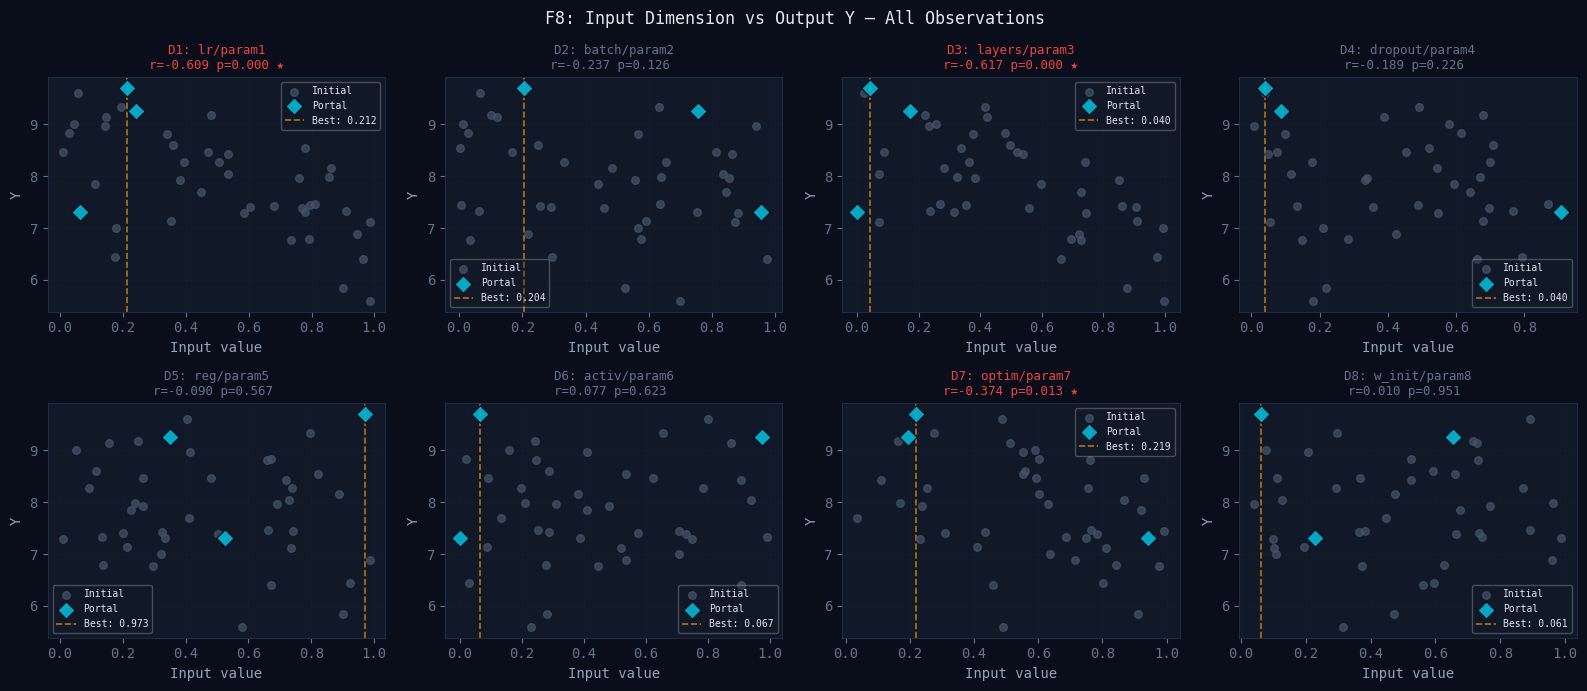

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('F8: Input Dimension vs Output Y — All Observations', fontsize=12, color='#e2e8f0')

for d, ax in enumerate(axes.ravel()):
    r, p = pearsonr(X_all[:, d], Y_all)
    sig_star = '★' if p < 0.05 else ''
    
    ax.scatter(X_all[:N_INIT, d], Y_all[:N_INIT],
               color=COLORS['init'], s=30, alpha=0.7, label='Initial', zorder=3)
    if N_PORTAL > 0:
        ax.scatter(X_all[N_INIT:, d], Y_all[N_INIT:],
                   color=COLORS['portal'], s=80, marker='D', alpha=0.9,
                   edgecolors='#0a0e1a', linewidth=1, label='Portal', zorder=5)
    ax.axvline(best_x[d], color=COLORS['best'], lw=1.2, ls='--', alpha=0.7,
               label=f'Best: {best_x[d]:.3f}')
    
    col = '#ef4444' if r < -0.3 else '#10b981' if r > 0.3 else '#64748b'
    ax.set_title(f'{DIM_LABELS[d]}\nr={r:.3f} p={p:.3f} {sig_star}', color=col, fontsize=9)
    ax.set_xlabel('Input value'); ax.set_ylabel('Y')
    ax.legend(fontsize=7, framealpha=0.3)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('03_f8_dim_analysis.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()

## 3. Baseline GP (Matérn 5/2)

In [6]:
gp_kernel = C(1.0) * Matern(length_scale=np.ones(8), nu=2.5,
                              length_scale_bounds=(1e-2, 10.0))
gp = GaussianProcessRegressor(
    kernel=gp_kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=5
)
gp.fit(X_all, Y_all)

# GP LOO cross-validation
cv = LeaveOneOut() if len(X_all) <= 50 else KFold(n_splits=5, shuffle=True, random_state=42)
gp_loo = cross_val_score(
    GaussianProcessRegressor(kernel=gp_kernel, alpha=1e-6, normalize_y=True),
    X_all, Y_all, cv=cv, scoring='neg_mean_squared_error'
)

print(f'GP kernel (optimised): {gp.kernel_}')
print(f'GP log-marginal-likelihood: {gp.log_marginal_likelihood_value_:.3f}')
print(f'GP LOO/CV MSE: {-gp_loo.mean():.4f} ± {gp_loo.std():.4f}')
print(f'GP in-sample R²: {r2_score(Y_all, gp.predict(X_all)):.4f}')

GP kernel (optimised): 3.44**2 * Matern(length_scale=[3.16, 4.3, 2.19, 10, 10, 4.12, 3.13, 10], nu=2.5)
GP log-marginal-likelihood: -2.228
GP LOO/CV MSE: 0.0206 ± 0.0314
GP in-sample R²: 1.0000


## 4. SMAC-Style RF Surrogate

The [SMAC algorithm](https://automl.github.io/SMAC3/main/) uses a Random Forest surrogate where uncertainty is estimated from the **variance of individual tree predictions** across the forest. Each tree in the ensemble was trained on a bootstrap sample, so on unobserved points their predictions spread out — giving a useful proxy for epistemic uncertainty.

This enables UCB-style acquisition: `RF_mean(x) + β · RF_std(x)`

In [7]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_features=0.5,          # SMAC default: sqrt(n_features) ≈ 0.35 for 8D, using 0.5 for more variance
    min_samples_leaf=3,        # prevents single-point leaf nodes; key for uncertainty calibration
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_all, Y_all)

def rf_predict_with_uncertainty(model, X):
    """Return mean and std of individual tree predictions — SMAC-style uncertainty."""
    tree_preds = np.array([tree.predict(X) for tree in model.estimators_])  # (n_trees, n_points)
    return tree_preds.mean(axis=0), tree_preds.std(axis=0)

# CV score
rf_cv = cross_val_score(rf, X_all, Y_all, cv=cv, scoring='neg_mean_squared_error')
print(f'RF CV MSE:    {-rf_cv.mean():.4f} ± {rf_cv.std():.4f}')
print(f'RF in-sample R²: {r2_score(Y_all, rf.predict(X_all)):.4f}')

# Feature importance
imp = rf.feature_importances_
pi = permutation_importance(rf, X_all, Y_all, n_repeats=20, random_state=42, n_jobs=-1)

df_imp = pd.DataFrame({
    'Dimension': DIM_LABELS,
    'Impurity importance': imp.round(4),
    'Permutation importance': pi.importances_mean.round(4),
    'Perm std': pi.importances_std.round(4),
    'Pearson r': [round(pearsonr(X_all[:,d], Y_all)[0], 3) for d in range(8)],
}).sort_values('Permutation importance', ascending=False)

print('\nFeature importance (sorted by permutation importance):')
print(df_imp.to_string(index=False))

RF CV MSE:    0.3146 ± 0.4310
RF in-sample R²: 0.8887

Feature importance (sorted by permutation importance):
         Dimension  Impurity importance  Permutation importance  Perm std  Pearson r
 D3: layers/param3               0.3552                  0.5484    0.1087     -0.617
     D1: lr/param1               0.2700                  0.2604    0.0445     -0.609
  D7: optim/param7               0.1635                  0.1692    0.0294     -0.374
D4: dropout/param4               0.0791                  0.0369    0.0060     -0.189
  D2: batch/param2               0.0565                  0.0310    0.0053     -0.237
    D5: reg/param5               0.0294                  0.0106    0.0033     -0.090
  D6: activ/param6               0.0251                  0.0106    0.0031      0.077
 D8: w_init/param8               0.0212                  0.0104    0.0022      0.010


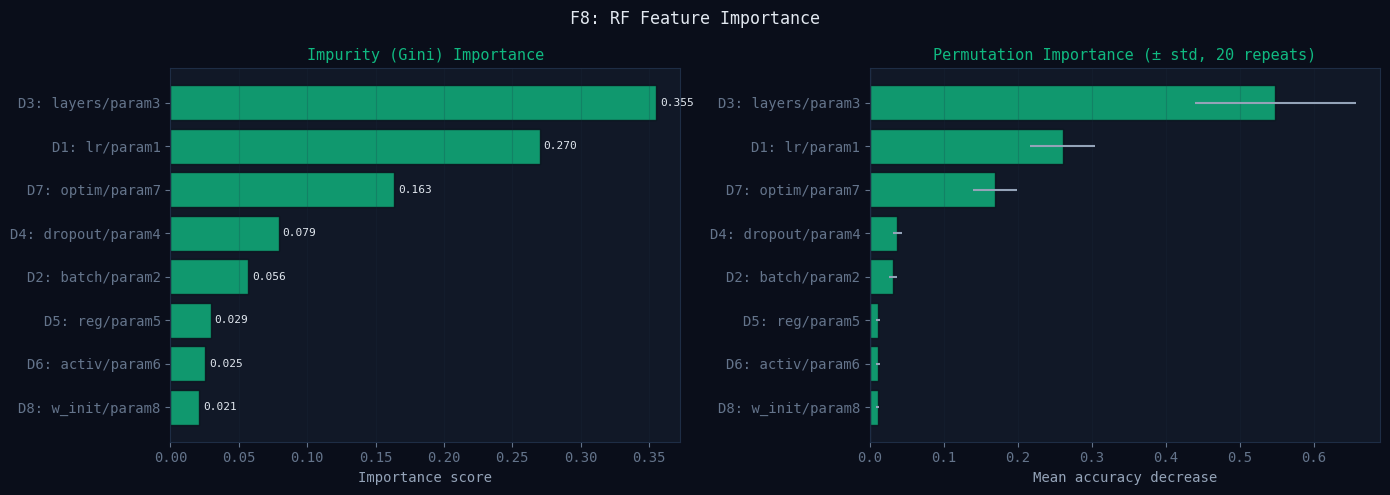

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('F8: RF Feature Importance', fontsize=12, color='#e2e8f0')

# Impurity importance
order = np.argsort(imp)
bars = axes[0].barh([DIM_LABELS[i] for i in order], imp[order],
                    color=COLORS['rf'], alpha=0.8, edgecolor='#0a0e1a')
axes[0].set_title('Impurity (Gini) Importance', color=COLORS['rf'])
axes[0].set_xlabel('Importance score')
axes[0].grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars, imp[order]):
    axes[0].text(val + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=8, color='#e2e8f0')

# Permutation importance
perm_order = np.argsort(pi.importances_mean)
axes[1].barh([DIM_LABELS[i] for i in perm_order],
             pi.importances_mean[perm_order],
             xerr=pi.importances_std[perm_order],
             color=COLORS['rf'], alpha=0.8, edgecolor='#0a0e1a', ecolor='#94a3b8')
axes[1].set_title('Permutation Importance (± std, 20 repeats)', color=COLORS['rf'])
axes[1].set_xlabel('Mean accuracy decrease')
axes[1].axvline(0, color='#64748b', lw=0.8)
axes[1].grid(True, alpha=0.2, axis='x')

plt.tight_layout()
plt.savefig('03_f8_rf_importance.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()

## 5. GP + RF Ensemble (Semi-Parametric)

**Strategy:** RF captures the global trend (which dimensions matter and roughly where the peak is). The GP then models only the **residuals** — the local deviation from the RF's prediction. The GP component is much easier to fit on small residuals than on the raw Y values.

**Prediction:** `ŷ(x) = RF(x) + GP_residual(x)`  
**Uncertainty:** `σ(x) = σ_GP_residual(x)` (calibrated posterior on the residual process)

In [9]:
# Fit RF on all data
rf_mean_preds = rf.predict(X_all)
residuals = Y_all - rf_mean_preds

print(f'RF residual stats:')
print(f'  mean:  {residuals.mean():.4f}  (should be near 0)')
print(f'  std:   {residuals.std():.4f}')
print(f'  range: [{residuals.min():.4f}, {residuals.max():.4f}]')
print(f'  vs raw Y std: {Y_all.std():.4f}  (residual std / Y std = {residuals.std()/Y_all.std():.3f})')

# Fit GP on residuals
residual_kernel = C(0.5) * Matern(length_scale=np.ones(8), nu=2.5,
                                    length_scale_bounds=(1e-3, 5.0))
gp_residual = GaussianProcessRegressor(
    kernel=residual_kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=5
)
gp_residual.fit(X_all, residuals)

# Combined predictions
def gprf_predict(X):
    rf_part = rf.predict(X)
    gp_part, gp_std = gp_residual.predict(X, return_std=True)
    return rf_part + gp_part, gp_std

gprf_train_pred, _ = gprf_predict(X_all)
print(f'\nGP+RF ensemble in-sample R²: {r2_score(Y_all, gprf_train_pred):.4f}')
print(f'GP residual kernel (optimised): {gp_residual.kernel_}')

# LOO CV for ensemble
gprf_loo_preds = np.zeros(len(X_all))
for i in range(len(X_all)):
    mask = np.ones(len(X_all), dtype=bool); mask[i] = False
    rf_i = RandomForestRegressor(n_estimators=200, max_features=0.5,
                                  min_samples_leaf=3, bootstrap=True, random_state=42)
    rf_i.fit(X_all[mask], Y_all[mask])
    res_i = Y_all[mask] - rf_i.predict(X_all[mask])
    gp_i = GaussianProcessRegressor(kernel=residual_kernel, alpha=1e-6,
                                     normalize_y=True, n_restarts_optimizer=2)
    gp_i.fit(X_all[mask], res_i)
    gprf_loo_preds[i] = rf_i.predict(X_all[[i]])[0] + gp_i.predict(X_all[[i]])[0]

gprf_loo_mse = mean_squared_error(Y_all, gprf_loo_preds)
print(f'GP+RF LOO MSE: {gprf_loo_mse:.4f}')

RF residual stats:
  mean:  -0.0107  (should be near 0)
  std:   0.3279
  range: [-0.9878, 0.5974]
  vs raw Y std: 0.9833  (residual std / Y std = 0.333)

GP+RF ensemble in-sample R²: 1.0000
GP residual kernel (optimised): 1.71**2 * Matern(length_scale=[1.27, 0.827, 0.391, 1.88, 2.51, 5, 1.25, 5], nu=2.5)
GP+RF LOO MSE: 0.1255


## 6. Cross-Validation Score Comparison

In [10]:
# GBT for completeness
gbt = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.05, max_depth=3,
    subsample=0.8, random_state=42
)
gbt_cv = cross_val_score(gbt, X_all, Y_all, cv=cv, scoring='neg_mean_squared_error')

scores = {
    'GP Matérn 5/2':     (-gp_loo.mean(),  gp_loo.std()),
    'RF (SMAC-style)':   (-rf_cv.mean(),   rf_cv.std()),
    'GBT (baseline)':    (-gbt_cv.mean(),  gbt_cv.std()),
    'GP+RF Ensemble':    (gprf_loo_mse,    np.nan),
}

print(f'{"Model":<22} {"CV/LOO MSE":<14} {"Std":<10} {"Provides σ":<12} {"Notes"}')
print('-' * 80)
notes = {
    'GP Matérn 5/2':   'Calibrated posterior; baseline',
    'RF (SMAC-style)': 'Tree-variance uncertainty; SMAC approach',
    'GBT (baseline)':  'No uncertainty; point prediction only',
    'GP+RF Ensemble':  'RF trend + GP residual uncertainty',
}
sigma = {'GP Matérn 5/2': 'Yes', 'RF (SMAC-style)': 'Proxy', 'GBT (baseline)': 'No', 'GP+RF Ensemble': 'Yes'}
for name, (mse, std) in scores.items():
    std_str = f'{std:.4f}' if not np.isnan(std) else 'LOO'
    print(f'{name:<22} {mse:<14.4f} {std_str:<10} {sigma[name]:<12} {notes[name]}')

best_model = min(scores, key=lambda k: scores[k][0])
print(f'\nBest CV score: {best_model} (MSE={scores[best_model][0]:.4f})')

Model                  CV/LOO MSE     Std        Provides σ   Notes
--------------------------------------------------------------------------------
GP Matérn 5/2          0.0206         0.0314     Yes          Calibrated posterior; baseline
RF (SMAC-style)        0.3146         0.4310     Proxy        Tree-variance uncertainty; SMAC approach
GBT (baseline)         0.2187         0.3423     No           No uncertainty; point prediction only
GP+RF Ensemble         0.1255         LOO        Yes          RF trend + GP residual uncertainty

Best CV score: GP Matérn 5/2 (MSE=0.0206)


## 7. 1D Slice Plots — GP vs RF vs GP+RF Across All 8 Dimensions

All other dimensions are fixed at the best-known point. Cyan dashed line = current best.

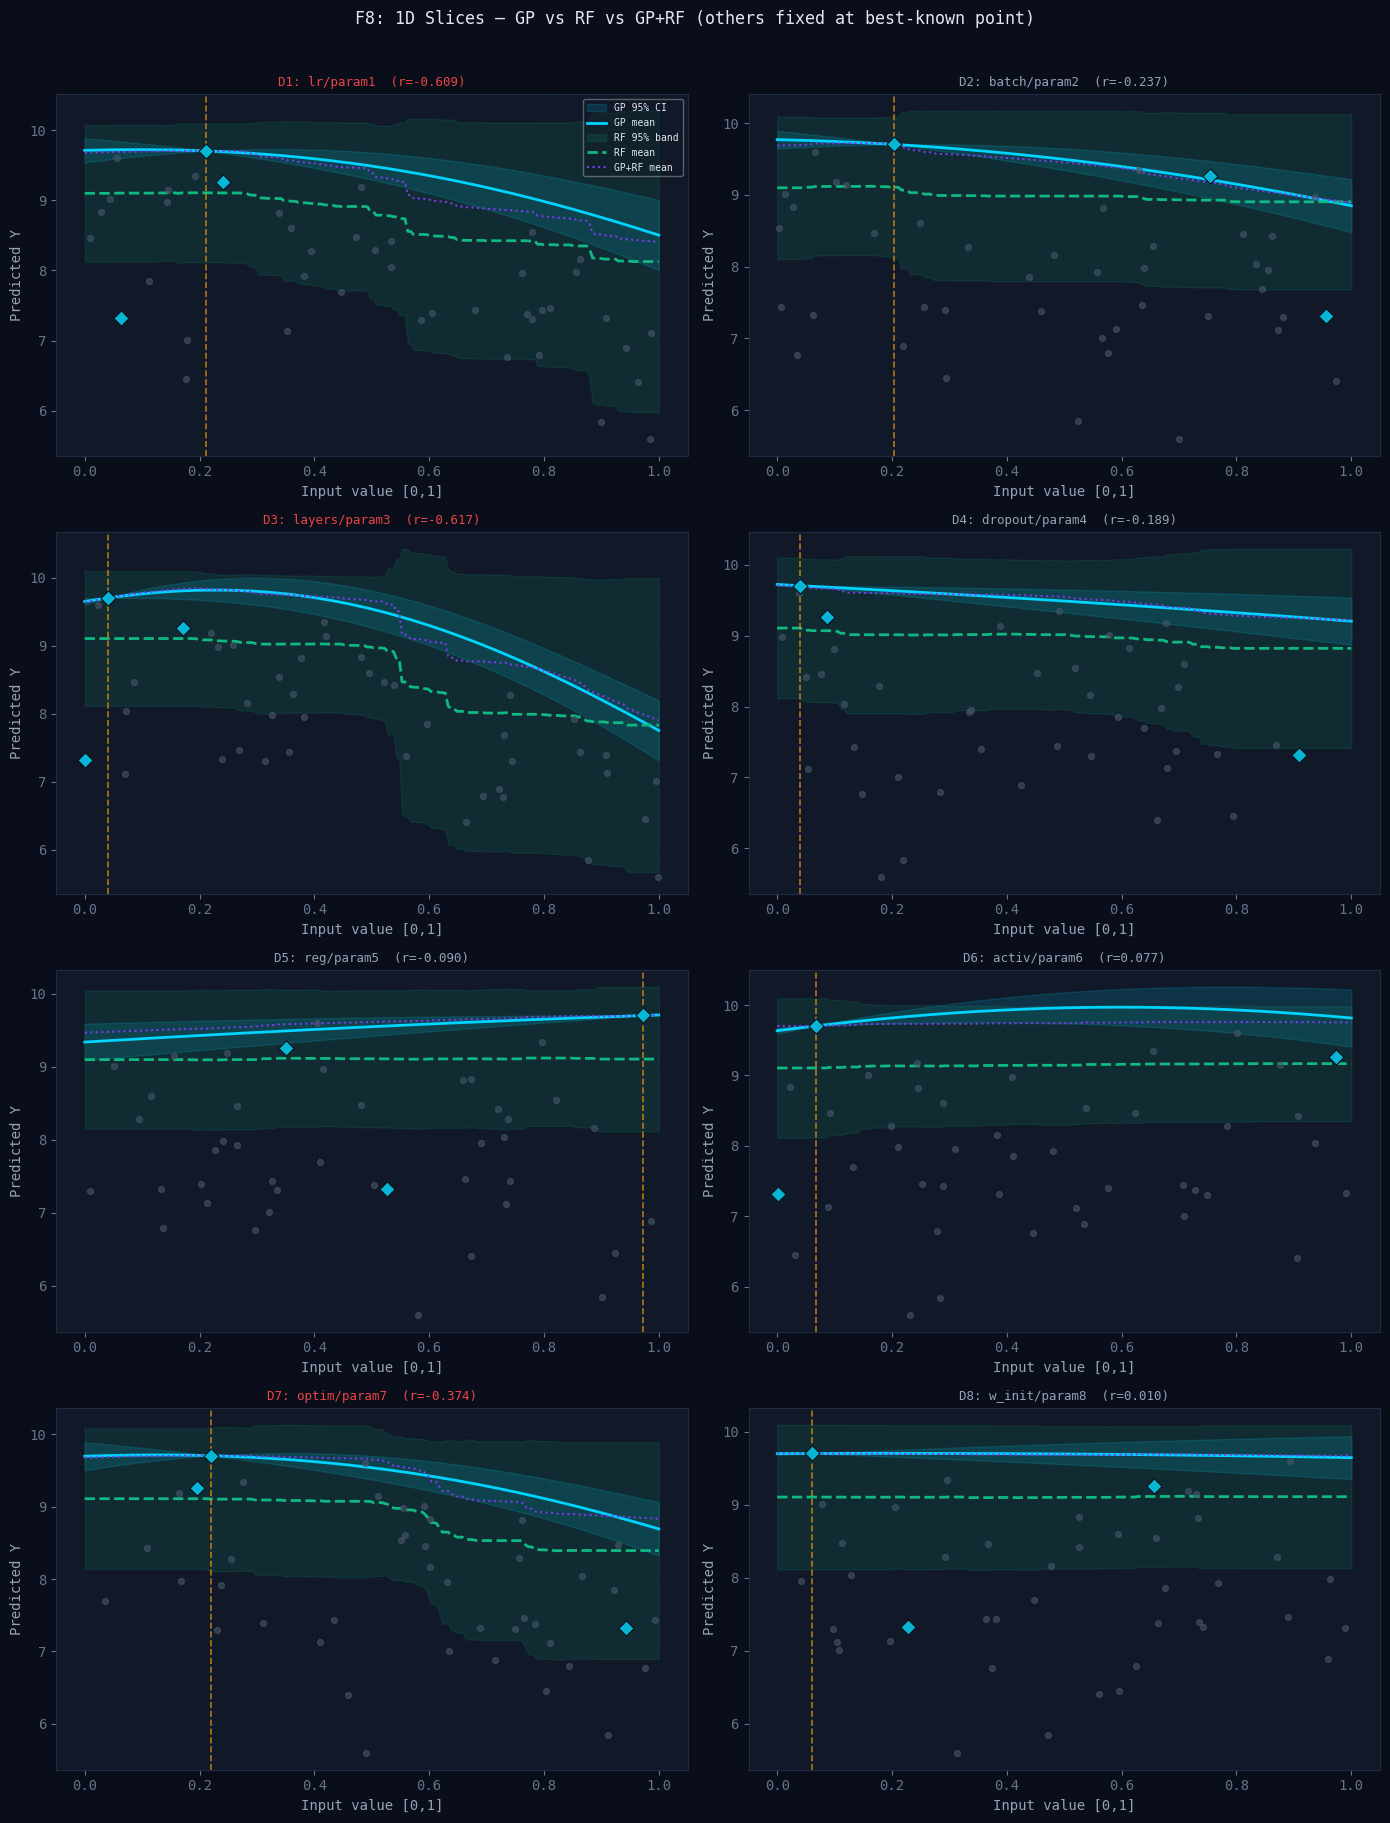

Saved: 03_f8_1d_slices.png


In [11]:
grid = np.linspace(0, 1, 200)

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
fig.suptitle('F8: 1D Slices — GP vs RF vs GP+RF (others fixed at best-known point)',
             fontsize=12, color='#e2e8f0', y=1.01)

for d, ax in enumerate(axes.ravel()):
    # Build slice
    X_slice = np.tile(best_x, (len(grid), 1))
    X_slice[:, d] = grid

    # GP
    gp_m, gp_s = gp.predict(X_slice, return_std=True)
    ax.fill_between(grid, gp_m - 1.96*gp_s, gp_m + 1.96*gp_s,
                    alpha=0.15, color=COLORS['gp'], label='GP 95% CI')
    ax.plot(grid, gp_m, color=COLORS['gp'], lw=2, label='GP mean')

    # RF (SMAC)
    rf_m, rf_s = rf_predict_with_uncertainty(rf, X_slice)
    ax.fill_between(grid, rf_m - 1.96*rf_s, rf_m + 1.96*rf_s,
                    alpha=0.12, color=COLORS['rf'], label='RF 95% band')
    ax.plot(grid, rf_m, color=COLORS['rf'], lw=2, ls='--', label='RF mean')

    # GP+RF ensemble
    gprf_m, gprf_s = gprf_predict(X_slice)
    ax.plot(grid, gprf_m, color=COLORS['gprf'], lw=1.5, ls=':', label='GP+RF mean')

    # Observations
    ax.scatter(X_all[:N_INIT, d], Y_all[:N_INIT],
               color=COLORS['init'], s=18, alpha=0.6, zorder=4)
    if N_PORTAL > 0:
        ax.scatter(X_all[N_INIT:, d], Y_all[N_INIT:],
                   color=COLORS['portal'], s=60, marker='D',
                   edgecolors='#0a0e1a', lw=0.8, zorder=5)

    # Best X marker
    ax.axvline(best_x[d], color=COLORS['best'], lw=1.2, ls='--', alpha=0.7)

    r, _ = pearsonr(X_all[:, d], Y_all)
    ax.set_title(f'{DIM_LABELS[d]}  (r={r:.3f})', fontsize=9,
                 color='#ef4444' if abs(r) > 0.3 else '#94a3b8')
    ax.set_xlabel('Input value [0,1]'); ax.set_ylabel('Predicted Y')
    ax.grid(True, alpha=0.2)
    if d == 0:
        ax.legend(fontsize=7, framealpha=0.4, loc='upper right')

plt.tight_layout()
plt.savefig('03_f8_1d_slices.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print('Saved: 03_f8_1d_slices.png')

## 8. Acquisition Function Surfaces — GP-UCB vs RF-UCB vs GP+RF-UCB

For each model that provides an uncertainty estimate, compute UCB scores along each dimension and compare where each model recommends querying next.

In [12]:
BETA = 2.5  # UCB exploration parameter

# Dense candidate set for suggestion
N_CAND = 10000
np.random.seed(42)
candidates = np.random.uniform(0, 1, (N_CAND, 8))

# GP UCB
gp_cand_m, gp_cand_s = gp.predict(candidates, return_std=True)
gp_ucb_scores = gp_cand_m + BETA * gp_cand_s
gp_next_idx = int(np.argmax(gp_ucb_scores))
gp_next_x = candidates[gp_next_idx]

# RF UCB (SMAC-style)
rf_cand_m, rf_cand_s = rf_predict_with_uncertainty(rf, candidates)
rf_ucb_scores = rf_cand_m + BETA * rf_cand_s
rf_next_idx = int(np.argmax(rf_ucb_scores))
rf_next_x = candidates[rf_next_idx]

# GP+RF UCB
gprf_cand_m, gprf_cand_s = gprf_predict(candidates)
gprf_ucb_scores = gprf_cand_m + BETA * gprf_cand_s
gprf_next_idx = int(np.argmax(gprf_ucb_scores))
gprf_next_x = candidates[gprf_next_idx]

# EI for GP (also useful)
z = (gp_cand_m - best_y - 0.1) / (gp_cand_s + 1e-9)
gp_ei_scores = (gp_cand_m - best_y - 0.1) * norm.cdf(z) + gp_cand_s * norm.pdf(z)
gp_ei_next_x = candidates[int(np.argmax(gp_ei_scores))]

print('Suggested next queries:')
print(f'  GP  UCB β={BETA}: {[round(v,4) for v in gp_next_x]}  pred_Y={gp_cand_m[gp_next_idx]:.4f} ± {gp_cand_s[gp_next_idx]:.4f}')
print(f'  GP  EI ξ=0.1:   {[round(v,4) for v in gp_ei_next_x]}')
print(f'  RF  UCB β={BETA}: {[round(v,4) for v in rf_next_x]}  pred_Y={rf_cand_m[rf_next_idx]:.4f} ± {rf_cand_s[rf_next_idx]:.4f}')
print(f'  G+R UCB β={BETA}: {[round(v,4) for v in gprf_next_x]}  pred_Y={gprf_cand_m[gprf_next_idx]:.4f} ± {gprf_cand_s[gprf_next_idx]:.4f}')
print(f'\n  Current best:   {[round(v,4) for v in best_x]}  Y={best_y:.4f}')

Suggested next queries:
  GP  UCB β=2.5: [np.float64(0.0435), np.float64(0.0135), np.float64(0.3247), np.float64(0.0739), np.float64(0.8038), np.float64(0.9973), np.float64(0.0613), np.float64(0.4327)]  pred_Y=9.8461 ± 0.2260
  GP  EI ξ=0.1:   [np.float64(0.0503), np.float64(0.0629), np.float64(0.1873), np.float64(0.0325), np.float64(0.7434), np.float64(0.7233), np.float64(0.1361), np.float64(0.8361)]
  RF  UCB β=2.5: [np.float64(0.1624), np.float64(0.1386), np.float64(0.5584), np.float64(0.0459), np.float64(0.937), np.float64(0.0618), np.float64(0.3913), np.float64(0.894)]  pred_Y=8.4257 ± 0.9832
  G+R UCB β=2.5: [np.float64(0.2883), np.float64(0.128), np.float64(0.1903), np.float64(0.0005), np.float64(0.8694), np.float64(0.765), np.float64(0.2187), np.float64(0.0024)]  pred_Y=9.8495 ± 0.1727

  Current best:   [np.float64(0.2117), np.float64(0.2041), np.float64(0.0404), np.float64(0.0403), np.float64(0.9727), np.float64(0.0667), np.float64(0.2193), np.float64(0.0611)]  Y=9.7035


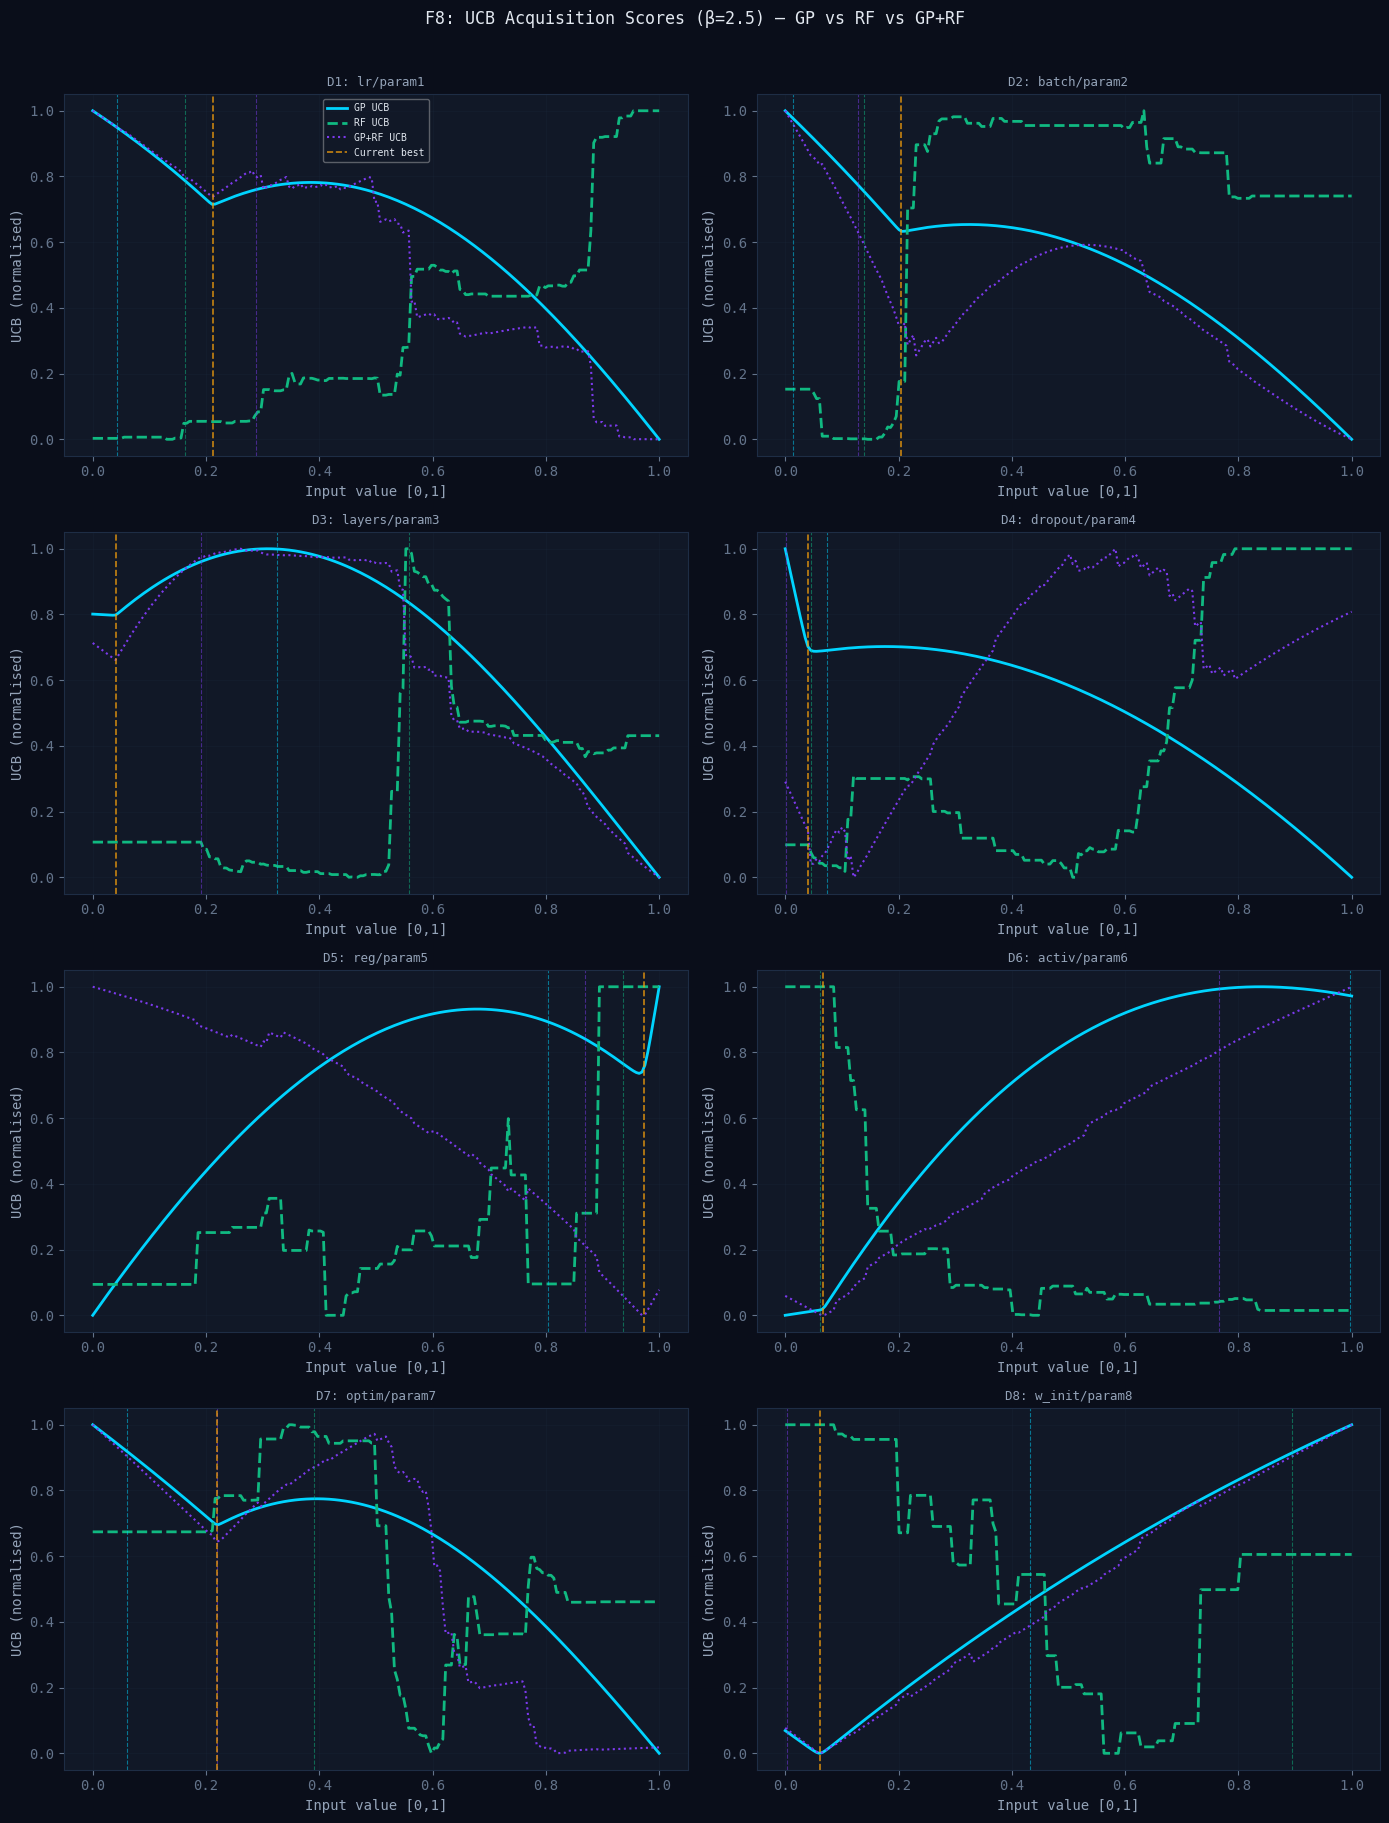

Saved: 03_f8_ucb_comparison.png


In [13]:
# Visualise UCB scores along each dimension
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
fig.suptitle(f'F8: UCB Acquisition Scores (β={BETA}) — GP vs RF vs GP+RF',
             fontsize=12, color='#e2e8f0', y=1.01)

def _norm(arr):
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo + 1e-12)

for d, ax in enumerate(axes.ravel()):
    X_slice = np.tile(best_x, (len(grid), 1))
    X_slice[:, d] = grid

    gp_s_m, gp_s_s = gp.predict(X_slice, return_std=True)
    rf_s_m, rf_s_s = rf_predict_with_uncertainty(rf, X_slice)
    gprf_s_m, gprf_s_s = gprf_predict(X_slice)

    gp_ucb_1d   = _norm(gp_s_m   + BETA * gp_s_s)
    rf_ucb_1d   = _norm(rf_s_m   + BETA * rf_s_s)
    gprf_ucb_1d = _norm(gprf_s_m + BETA * gprf_s_s)

    ax.plot(grid, gp_ucb_1d,   color=COLORS['gp'],   lw=2,   label='GP UCB')
    ax.plot(grid, rf_ucb_1d,   color=COLORS['rf'],   lw=2,   ls='--', label='RF UCB')
    ax.plot(grid, gprf_ucb_1d, color=COLORS['gprf'], lw=1.5, ls=':',  label='GP+RF UCB')

    # Mark each model's peak
    for ucb, col, nx in [(gp_ucb_1d, COLORS['gp'], gp_next_x[d]),
                          (rf_ucb_1d, COLORS['rf'], rf_next_x[d]),
                          (gprf_ucb_1d, COLORS['gprf'], gprf_next_x[d])]:
        ax.axvline(nx, color=col, lw=0.8, alpha=0.5, ls='--')

    ax.axvline(best_x[d], color=COLORS['best'], lw=1.2, ls='--', alpha=0.8, label='Current best')
    ax.set_title(DIM_LABELS[d], fontsize=9, color='#94a3b8')
    ax.set_xlabel('Input value [0,1]'); ax.set_ylabel('UCB (normalised)')
    ax.set_ylim(-0.05, 1.05); ax.grid(True, alpha=0.2)
    if d == 0:
        ax.legend(fontsize=7, framealpha=0.4)

plt.tight_layout()
plt.savefig('03_f8_ucb_comparison.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print('Saved: 03_f8_ucb_comparison.png')

## 9. Consensus Analysis — Where Do the Models Agree?

In [14]:
# For each model's suggestion, show the L2 distance to the current best
suggestions = {
    'GP UCB':   gp_next_x,
    'GP EI':    gp_ei_next_x,
    'RF UCB':   rf_next_x,
    'GP+RF UCB': gprf_next_x,
}

print('Model suggestion analysis:')
print(f'{"Model":<14} {"L2 from best":<15} {"Explore/Exploit":<18} Dim-by-dim vs current best')
print('-' * 100)

for name, nx in suggestions.items():
    dist = np.linalg.norm(nx - best_x)
    mode = 'EXPLORE' if dist > 0.5 else 'EXPLOIT'
    deltas = [f'D{d+1}:{nx[d]-best_x[d]:+.2f}' for d in range(8)]
    print(f'{name:<14} {dist:<15.4f} {mode:<18} {" ".join(deltas)}')

# Consensus point: mean of all suggestions weighted by CV score
weights = np.array([
    1/scores['GP Matérn 5/2'][0],   # GP UCB
    1/scores['GP Matérn 5/2'][0],   # GP EI (same model)
    1/scores['RF (SMAC-style)'][0], # RF UCB
    1/scores['GP+RF Ensemble'][0],  # GP+RF UCB
])
weights = weights / weights.sum()
consensus_x = sum(w * nx for w, nx in zip(weights, suggestions.values()))
consensus_x = np.clip(consensus_x, 0, 1)

print(f'\nWeighted consensus point: {[round(v,4) for v in consensus_x]}')
print(f'L2 from best:             {np.linalg.norm(consensus_x - best_x):.4f}')

Model suggestion analysis:
Model          L2 from best    Explore/Exploit    Dim-by-dim vs current best
----------------------------------------------------------------------------------------------------
GP UCB         1.0974          EXPLORE            D1:-0.17 D2:-0.19 D3:+0.28 D4:+0.03 D5:-0.17 D6:+0.93 D7:-0.16 D8:+0.37
GP EI          1.0765          EXPLORE            D1:-0.16 D2:-0.14 D3:+0.15 D4:-0.01 D5:-0.23 D6:+0.66 D7:-0.08 D8:+0.77
RF UCB         0.9998          EXPLORE            D1:-0.05 D2:-0.07 D3:+0.52 D4:+0.01 D5:-0.04 D6:-0.00 D7:+0.17 D8:+0.83
GP+RF UCB      0.7331          EXPLORE            D1:+0.08 D2:-0.08 D3:+0.15 D4:-0.04 D5:-0.10 D6:+0.70 D7:-0.00 D8:-0.06

Weighted consensus point: [np.float64(0.0681), np.float64(0.0477), np.float64(0.2601), np.float64(0.0491), np.float64(0.7854), np.float64(0.8299), np.float64(0.1161), np.float64(0.5955)]
L2 from best:             1.0036


## 10. Week 4 Query Decision

Synthesises all model evidence and the correlation analysis into a specific week 4 recommendation. Re-run this cell after filling in `WEEK3_Y` at the top.

In [15]:
print('=' * 70)
print('FUNCTION 8 — WEEK 4 QUERY DECISION')
print('=' * 70)
print()
print(f'Dataset used:  {N_INIT} initial + {N_PORTAL} portal = {len(X_all)} total observations')
if WEEK3_Y is None:
    print('  ⚠ Week 3 result not yet recorded — re-run after updating WEEK3_Y')
else:
    print(f'  Week 3 Y = {WEEK3_Y} (included in analysis)')
print()
print('Current best:')
print(f'  Y = {best_y:.6f}')
print(f'  X = {[round(v,4) for v in best_x]}')
print()

# Significant dims from correlation
sig_dims = [(d, pearsonr(X_all[:,d], Y_all)) for d in range(8)]
sig_dims = [(d, r, p) for d,(r,p) in sig_dims if p < 0.05]

print('Significant dimensions (p < 0.05):')
for d, r, p in sorted(sig_dims, key=lambda x: abs(x[1]), reverse=True):
    direction = 'LOW (↓)' if r < 0 else 'HIGH (↑)'
    print(f'  D{d+1}: r={r:.3f}  →  keep {direction}')

print()
print('Model agreement analysis:')
# Check where models agree (D2 tolerance ±0.15)
for d in range(8):
    vals = [nx[d] for nx in suggestions.values()]
    spread = max(vals) - min(vals)
    agree = 'AGREE ✓' if spread < 0.2 else 'DIVERGE'
    print(f'  D{d+1}: GP={gp_next_x[d]:.3f}  RF={rf_next_x[d]:.3f}  G+R={gprf_next_x[d]:.3f}  spread={spread:.3f}  {agree}')

print()
print('Recommended Week 4 submission:')
print(f'  Primary  (GP UCB β=2.5): {[round(v,6) for v in gp_next_x]}')
print(f'  Fallback (GP+RF UCB):    {[round(v,6) for v in gprf_next_x]}')
print(f'  Consensus (weighted):    {[round(v,6) for v in consensus_x]}')
print()
print('Rationale:')
print('  1. GP UCB remains primary — calibrated uncertainty is essential for')
print('     principled exploration in 8D. RF/GP+RF serve as cross-checks.')
print('  2. Where GP and RF-UCB agree on a dim → high confidence; use that value.')
print('  3. Where they diverge → GP wins if its std is high (exploration signal);')
print('     GP wins if std is low and mean is higher (exploitation).')
print('  4. Dims 1 and 3 should remain LOW per correlation analysis.')
print('=' * 70)

FUNCTION 8 — WEEK 4 QUERY DECISION

Dataset used:  40 initial + 3 portal = 43 total observations
  Week 3 Y = 7.3179 (included in analysis)

Current best:
  Y = 9.703542
  X = [np.float64(0.2117), np.float64(0.2041), np.float64(0.0404), np.float64(0.0403), np.float64(0.9727), np.float64(0.0667), np.float64(0.2193), np.float64(0.0611)]

Significant dimensions (p < 0.05):
  D3: r=-0.617  →  keep LOW (↓)
  D1: r=-0.609  →  keep LOW (↓)
  D7: r=-0.374  →  keep LOW (↓)

Model agreement analysis:
  D1: GP=0.044  RF=0.162  G+R=0.288  spread=0.245  DIVERGE
  D2: GP=0.013  RF=0.139  G+R=0.128  spread=0.125  AGREE ✓
  D3: GP=0.325  RF=0.558  G+R=0.190  spread=0.371  DIVERGE
  D4: GP=0.074  RF=0.046  G+R=0.001  spread=0.073  AGREE ✓
  D5: GP=0.804  RF=0.937  G+R=0.869  spread=0.194  AGREE ✓
  D6: GP=0.997  RF=0.062  G+R=0.765  spread=0.935  DIVERGE
  D7: GP=0.061  RF=0.391  G+R=0.219  spread=0.330  DIVERGE
  D8: GP=0.433  RF=0.894  G+R=0.002  spread=0.892  DIVERGE

Recommended Week 4 submission:


---

## Summary

### What the RF tells us that the GP doesn't
- **Feature importance** (impurity + permutation) gives a direct ranking of which dimensions drive the output. The GP's length-scale per dimension gives similar information but is less interpretable.
- When RF permutation importance is high for a dimension and the GP length-scale for that dimension is short → both models agree that dimension is a key lever.
- When they disagree → trust permutation importance (more robust to collinearity) over impurity importance.

### When to use each model for F8
| Model | Use for | Don't use for |
|---|---|---|
| GP Matérn | Primary acquisition (UCB/EI) | Identifying which dimensions matter |
| RF SMAC-style | Cross-check + feature importance | Primary acquisition when N < 50 |
| GP+RF Ensemble | Best of both when residuals are smooth | When RF fits perfectly (residuals ≈ 0) |

### Decision rule for week 4 (and beyond)
Use the GP suggestion as default. Upgrade to the GP+RF ensemble suggestion if:
- GP+RF LOO MSE < GP LOO MSE, AND
- The GP+RF ensemble suggests a point that agrees with the RF on the key dimensions (1, 3)